### Imports and dataset path

In [27]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat

In [4]:
DATASET_DIR = Path("../dataset/raw/CoconutLeaves")

print("Dataset path:", DATASET_DIR.resolve())
print("Dataset exists:", DATASET_DIR.exists())

Dataset path: C:\Users\Abdullah\Desktop\Final_Project\ai-coconut-leaf-disease-recommender\dataset\raw\CoconutLeaves
Dataset exists: True


### Inspect dataset structure

In [5]:
items = sorted(DATASET_DIR.iterdir())

for item in items:
    print(
        f"{item.name} -> {'folder' if item.is_dir() else 'file'}"
    )

CCI_Caterpillars -> folder
CCI_Leaflets -> folder
Gray Leaf Spot -> folder
Healthy_Leaves -> folder
Leaf Rot -> folder
WCLWD_DryingofLeaflets -> folder
WCLWD_Flaccidity -> folder
WCLWD_Yellowing -> folder


In [6]:
class_folders = sorted(
    [folder for folder in DATASET_DIR.iterdir() if folder.is_dir()]
)

print("Number of classes:", len(class_folders))

Number of classes: 8


### Dataset audit DataFrame

In [8]:
records = []

valid_extensions = {".jpg", ".jpeg", ".png"}

for folder in class_folders:
    for file_path in folder.rglob("*"):

        if not file_path.is_file():
            continue

        extension = file_path.suffix.lower()

        if extension not in valid_extensions:
            continue

        try:
            with Image.open(file_path) as img:
                img.load()

                width, height = img.size

                records.append({
                    "class": folder.name,
                    "filename": file_path.name,
                    "file_path": str(file_path),
                    "extension": extension,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                    "mode": img.mode,
                    "valid": True,
                })

        except Exception as error:
            records.append({
                "class": folder.name,
                "filename": file_path.name,
                "file_path": str(file_path),
                "extension": extension,
                "width": np.nan,
                "height": np.nan,
                "aspect_ratio": np.nan,
                "mode": None,
                "valid": False,
            })

df = pd.DataFrame(records)

print("Total images scanned:", len(df))
df

Total images scanned: 8947


,class,filename,file_path,extension,width,height,aspect_ratio,mode,valid
0,CCI_Caterpillars,CCI_10_0_jpg.rf.041b1c4c936db7346c0e1cc66e6877...,..\dataset\raw\CoconutLeaves\CCI_Caterpillars\...,.jpg,416,416,1.0,RGB,True
1,CCI_Caterpillars,CCI_10_0_jpg.rf.3dd177f566df40db63c0b8715d30c0...,..\dataset\raw\CoconutLeaves\CCI_Caterpillars\...,.jpg,416,416,1.0,RGB,True
2,CCI_Caterpillars,CCI_10_0_jpg.rf.4213fa6363674e98425c19dbb952da...,..\dataset\raw\CoconutLeaves\CCI_Caterpillars\...,.jpg,416,416,1.0,RGB,True
3,CCI_Caterpillars,CCI_10_104_jpg.rf.5c3bbbe5bb16823713de92fa3647...,..\dataset\raw\CoconutLeaves\CCI_Caterpillars\...,.jpg,416,416,1.0,RGB,True
4,CCI_Caterpillars,CCI_10_104_jpg.rf.8e80a645817ecfbe965f6a86b422...,..\dataset\raw\CoconutLeaves\CCI_Caterpillars\...,.jpg,416,416,1.0,RGB,True
...,...,...,...,...,...,...,...,...,...
8942,WCLWD_Yellowing,f_aug_0_9968.jpeg,..\dataset\raw\CoconutLeaves\WCLWD_Yellowing\f...,.jpeg,750,750,1.0,RGB,True
8943,WCLWD_Yellowing,f_aug_0_9973.jpeg,..\dataset\raw\CoconutLeaves\WCLWD_Yellowing\f...,.jpeg,750,750,1.0,RGB,True
8944,WCLWD_Yellowing,f_aug_0_9984.jpeg,..\dataset\raw\CoconutLeaves\WCLWD_Yellowing\f...,.jpeg,750,750,1.0,RGB,True
8945,WCLWD_Yellowing,f_aug_0_9992.jpeg,..\dataset\raw\CoconutLeaves\WCLWD_Yellowing\f...,.jpeg,750,750,1.0,RGB,True


### Dataset summary

In [10]:
summary = (
    df.groupby("class")
      .agg(
          total_images=("filename", "count"),
          valid_images=("valid", "sum"),
          avg_width=("width", "mean"),
          avg_height=("height", "mean"),
      )
      .round(1)
      .reset_index()
)

summary["corrupt_images"] = (
    summary["total_images"] - summary["valid_images"]
)

summary

,class,total_images,valid_images,avg_width,avg_height,corrupt_images
0,CCI_Caterpillars,990,990,416.0,416.0,0
1,CCI_Leaflets,795,795,1738.0,1897.2,0
2,Gray Leaf Spot,2135,2135,768.0,1004.7,0
3,Healthy_Leaves,123,123,640.0,640.0,0
4,Leaf Rot,1673,1673,768.0,1024.0,0
5,WCLWD_DryingofLeaflets,1078,1078,784.7,770.9,0
6,WCLWD_Flaccidity,1069,1069,785.0,770.4,0
7,WCLWD_Yellowing,1084,1084,784.5,770.4,0


In [11]:
print("Total images:", len(df))
print("Valid images:", int(df["valid"].sum()))
print("Corrupted images:", int((~df["valid"]).sum()))
print("Number of classes:", df["class"].nunique())

Total images: 8947
Valid images: 8947
Corrupted images: 0
Number of classes: 8


### Class distribution

In [12]:
class_counts = (
    df[df["valid"]]
    ["class"]
    .value_counts()
    .sort_values(ascending=False)
)

class_counts

class
Gray Leaf Spot            2135
Leaf Rot                  1673
WCLWD_Yellowing           1084
WCLWD_DryingofLeaflets    1078
WCLWD_Flaccidity          1069
CCI_Caterpillars           990
CCI_Leaflets               795
Healthy_Leaves             123
Name: count, dtype: int64

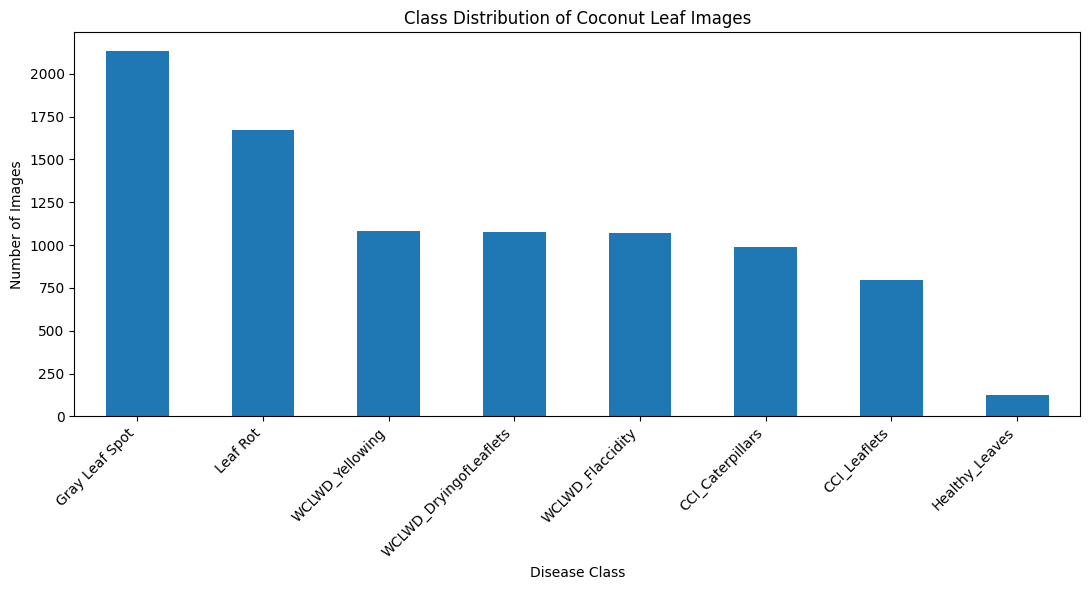

In [13]:
plt.figure(figsize=(11, 6))

class_counts.plot(kind="bar")

plt.title("Class Distribution of Coconut Leaf Images")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

### Class percentage and imbalance

In [14]:
class_distribution = pd.DataFrame({
    "image_count": class_counts,
    "percentage": (
        class_counts / class_counts.sum() * 100
    ).round(2)
})

class_distribution

,image_count,percentage
class,,
Gray Leaf Spot,2135,23.86
Leaf Rot,1673,18.70
WCLWD_Yellowing,1084,12.12
WCLWD_DryingofLeaflets,1078,12.05
WCLWD_Flaccidity,1069,11.95
CCI_Caterpillars,990,11.07
CCI_Leaflets,795,8.89
Healthy_Leaves,123,1.37


In [15]:
largest_class = class_counts.idxmax()
smallest_class = class_counts.idxmin()

largest_count = class_counts.max()
smallest_count = class_counts.min()

imbalance_ratio = largest_count / smallest_count

print("Largest class:", largest_class, "-", largest_count)
print("Smallest class:", smallest_class, "-", smallest_count)
print("Largest-to-smallest ratio:", round(imbalance_ratio, 2))

Largest class: Gray Leaf Spot - 2135
Smallest class: Healthy_Leaves - 123
Largest-to-smallest ratio: 17.36


### Image dimension analysis

In [17]:
dimension_counts = (
    df[df["valid"]]
    .groupby(["width", "height"])
    .size()
    .reset_index(name="image_count")
    .sort_values("image_count", ascending=False)
)

print("Number of unique image dimensions:", len(dimension_counts))

dimension_counts.head(15)

Number of unique image dimensions: 11


,width,height,image_count
4,768,1024,3716
2,750,750,3201
0,416,416,990
5,1080,1920,557
7,3520,1980,202
1,640,640,123
3,768,576,92
6,1920,1080,36
10,4496,3000,28
8,4459,2271,1


In [18]:
valid_df = df[df["valid"]]

print("Minimum width:", int(valid_df["width"].min()))
print("Maximum width:", int(valid_df["width"].max()))

print("Minimum height:", int(valid_df["height"].min()))
print("Maximum height:", int(valid_df["height"].max()))

Minimum width: 416
Maximum width: 4496
Minimum height: 416
Maximum height: 3000


### Aspect-ratio visualization

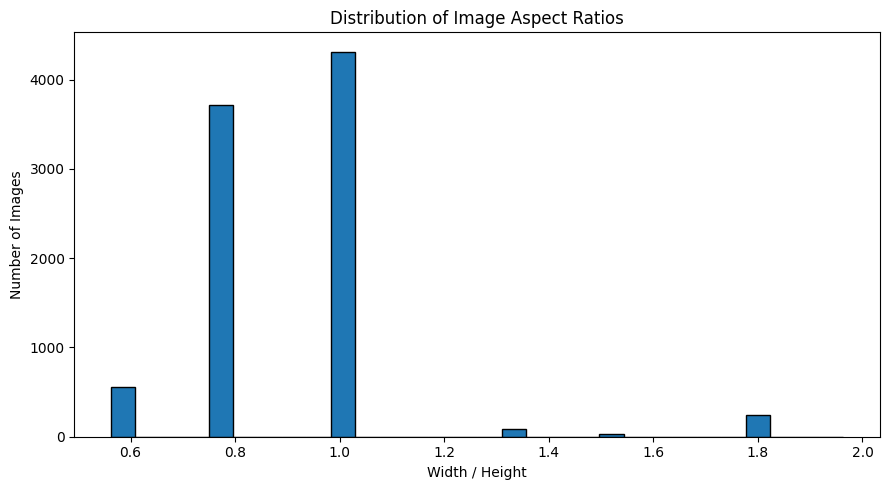

In [19]:
plt.figure(figsize=(9, 5))

plt.hist(
    valid_df["aspect_ratio"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Image Aspect Ratios")
plt.xlabel("Width / Height")
plt.ylabel("Number of Images")
plt.tight_layout()

plt.show()

### Image colour modes

In [20]:
mode_counts = valid_df["mode"].value_counts()

mode_counts

mode
RGB    8947
Name: count, dtype: int64

### File extension analysis

In [21]:
extension_counts = valid_df["extension"].value_counts()

extension_counts

extension
.jpg     5746
.jpeg    3201
Name: count, dtype: int64

### Corrupted image report

In [22]:
corrupted_images = df[df["valid"] == False]

print("Corrupted images:", len(corrupted_images))

corrupted_images[
    ["class", "filename", "file_path"]
]

Corrupted images: 0


,class,filename,file_path


### Duplicate-image detection

In [23]:
import hashlib

In [24]:
hash_records = {}

duplicate_pairs = []

for file_path in valid_df["file_path"]:

    with open(file_path, "rb") as file:
        file_hash = hashlib.md5(file.read()).hexdigest()

    if file_hash in hash_records:
        duplicate_pairs.append({
            "original": hash_records[file_hash],
            "duplicate": file_path
        })
    else:
        hash_records[file_hash] = file_path

duplicates_df = pd.DataFrame(duplicate_pairs)

print("Exact duplicate images:", len(duplicates_df))

duplicates_df

Exact duplicate images: 35


,original,duplicate
0,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...
1,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...
2,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...
3,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...
4,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...
5,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...
6,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...
7,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...
8,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...
9,..\dataset\raw\CoconutLeaves\Gray Leaf Spot\Gr...,..\dataset\raw\CoconutLeaves\Leaf Rot\LeafRot0...


### Sample images from each class

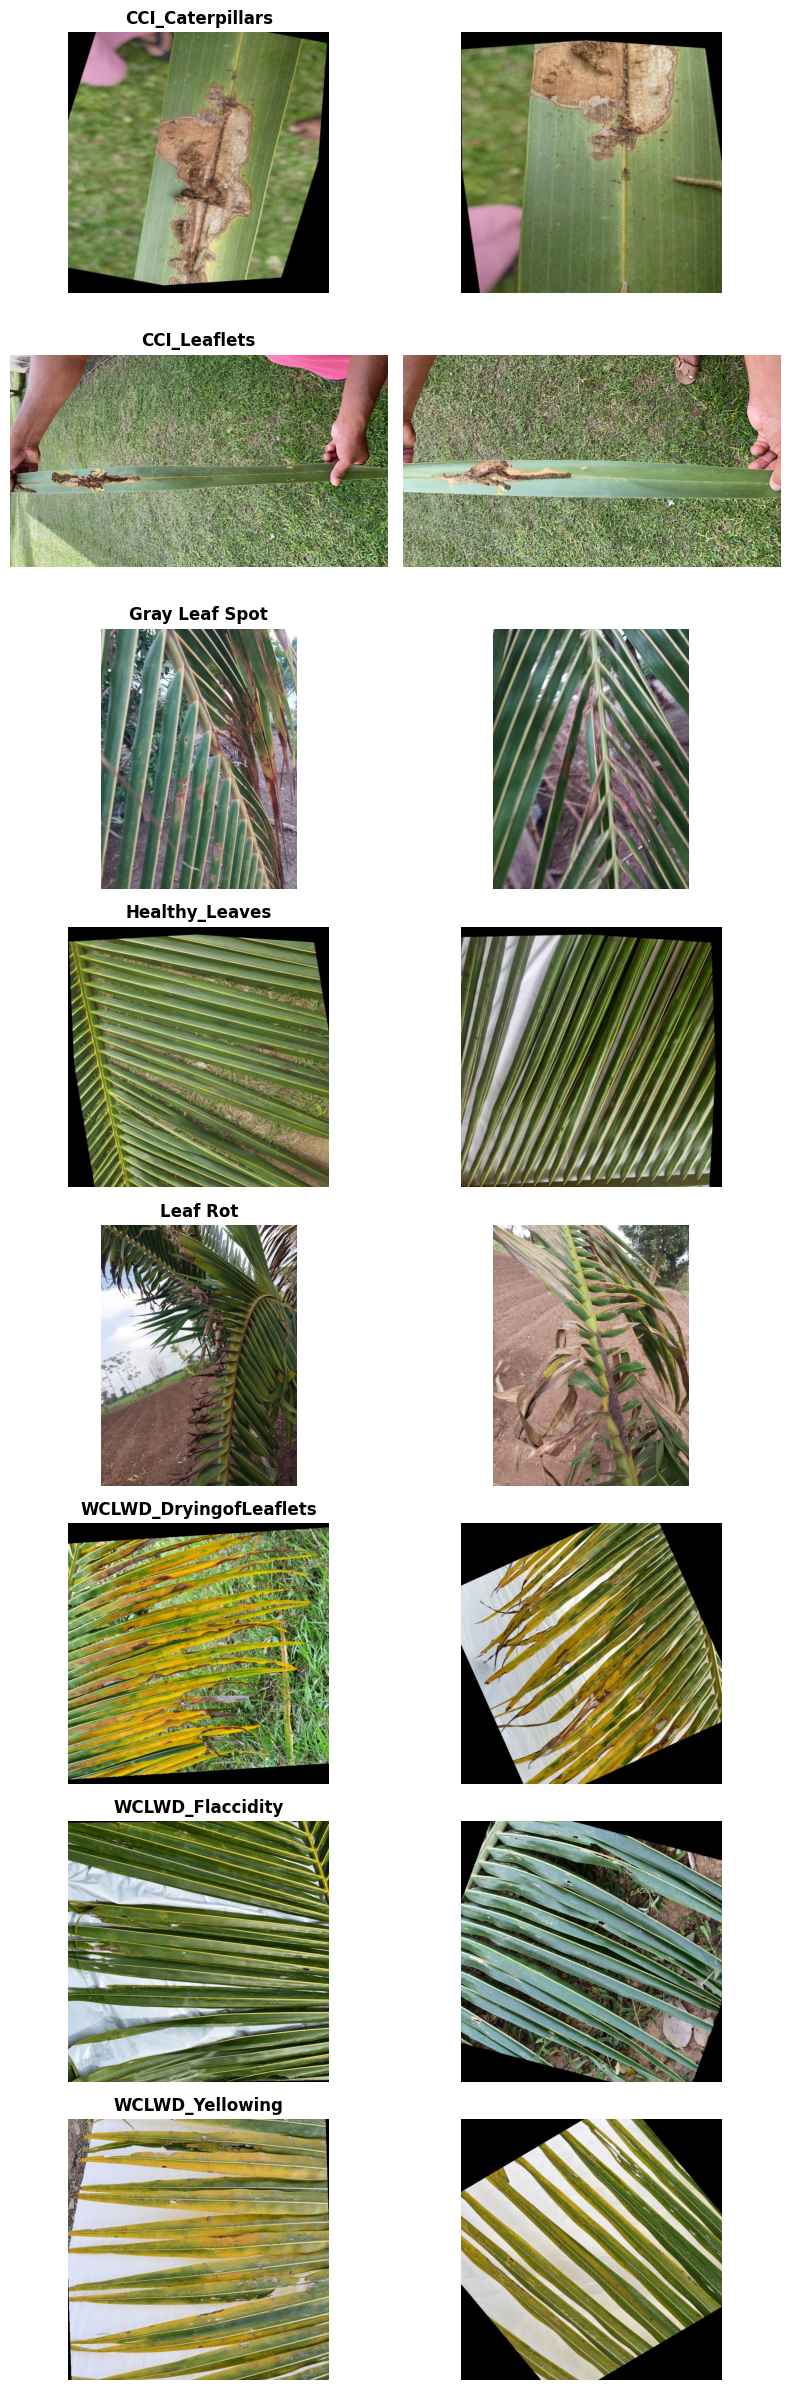

In [25]:
classes = sorted(valid_df["class"].unique())

fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=2,
    figsize=(8, len(classes) * 3)
)

for row, class_name in enumerate(classes):

    samples = (
        valid_df[valid_df["class"] == class_name]
        .sample(
            n=min(2, len(valid_df[valid_df["class"] == class_name])),
            random_state=42
        )
    )

    for col, (_, sample) in enumerate(samples.iterrows()):

        image = Image.open(sample["file_path"]).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(
                class_name,
                fontweight="bold"
            )

plt.tight_layout()
plt.show()

### Brightness analysis

In [28]:
brightness_records = []

for _, row in valid_df.iterrows():

    with Image.open(row["file_path"]) as img:
        grayscale = img.convert("L")
        brightness = ImageStat.Stat(grayscale).mean[0]

    brightness_records.append(brightness)

valid_df = valid_df.copy()
valid_df["brightness"] = brightness_records

In [29]:
brightness_summary = (
    valid_df.groupby("class")["brightness"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

brightness_summary

,mean,std,min,max
class,,,,
CCI_Caterpillars,119.98,7.93,82.38,157.08
CCI_Leaflets,121.29,11.59,93.29,165.20
Gray Leaf Spot,116.83,14.79,54.55,161.88
Healthy_Leaves,107.95,22.24,72.38,188.49
Leaf Rot,119.78,15.68,70.86,161.88
WCLWD_DryingofLeaflets,115.27,15.53,80.51,177.86
WCLWD_Flaccidity,92.15,17.17,49.52,140.92
WCLWD_Yellowing,116.71,14.44,74.68,156.66


<Figure size 1100x600 with 0 Axes>

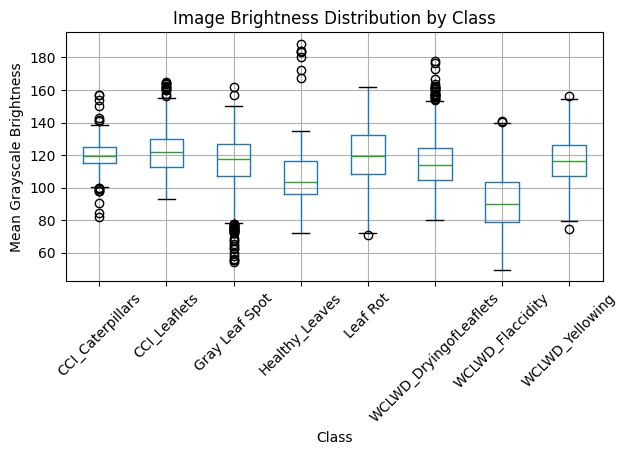

In [31]:
plt.figure(figsize=(11, 6))

valid_df.boxplot(
    column="brightness",
    by="class",
    rot=45
)

plt.title("Image Brightness Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Mean Grayscale Brightness")
plt.tight_layout()

plt.show()

### Correlation analysis

In [32]:
numeric_features = valid_df[
    [
        "width",
        "height",
        "aspect_ratio",
        "brightness"
    ]
]

correlation_matrix = numeric_features.corr()

correlation_matrix

,width,height,aspect_ratio,brightness
width,1.000000,0.703160,0.532504,0.109428
height,0.703160,1.000000,-0.187236,0.142536
aspect_ratio,0.532504,-0.187236,1.000000,-0.048458
brightness,0.109428,0.142536,-0.048458,1.000000


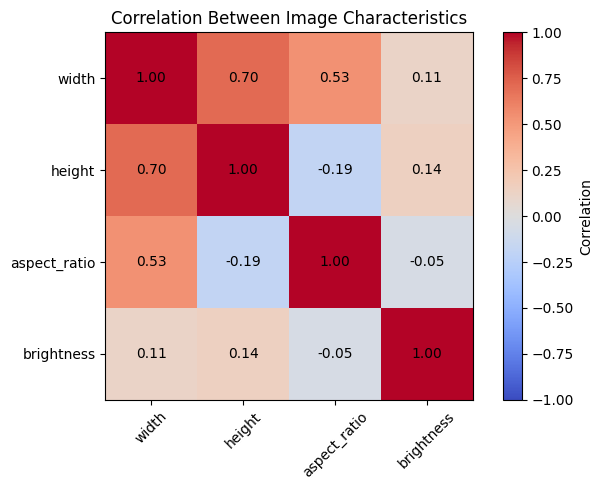

In [33]:
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Between Image Characteristics")
plt.tight_layout()

plt.show()

## EDA Findings

The dataset contains nine coconut leaf health and disease classes with a total of 9,461 images.

The exploratory analysis identified substantial class imbalance, particularly between Gray Leaf Spot and Healthy Leaves. Therefore, accuracy alone would not be sufficient for model evaluation. Macro precision, recall, and F1-score will also be considered.

The dataset contains images with different resolutions and aspect ratios. Consequently, images will be standardized to a common input size before model training.

Image brightness also varies across the dataset, indicating differences in lighting conditions. Data augmentation will therefore be considered to improve robustness.

Corrupted-image and duplicate-image checks were performed to reduce data-quality issues prior to training.